In [115]:
#Importando as bibliotecas que vão ser utilizadas

import pandas as pd
import numpy as np

In [116]:
#Importando os dados
dados = "/content/drive/MyDrive/Python - Capacitação de Dados - Notebooks/Analise/Campe_Supply_Corrompido.xlsx"

#Abrindo
dataset = pd.read_excel(dados)

#Visualizar
dataset.head()

#Excluir colunas que não são utilizadas
dataset = dataset.drop(columns=["UNNAMED: 0", "coluna_inutil_0", "coluna_inutil_1"])

#Renomear essas colunas
dataset.columns = ["Data de Venda","Setor","Produto","Vendedor","Região","Estado","Cliente","Faturamento","Margem de Lucro","Lucro"]

#Visualizar
dataset.head()

,Data de Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem de Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,633.45,0.13,82.3485
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,611.4,0.07,42.798
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,721.52,0.08,NaN
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,679.39,0.09,61.1451
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,0.19,183.2588


Analise Exploratória dos Dados

In [117]:
#Analise Exploratória dos Dados

#Visão Geral do Dataset
dataset.info()

#Verificando a quantidade de valores ausentes
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Data de Venda    1606 non-null   datetime64[ns]
 1   Setor            1604 non-null   object        
 2   Produto          1607 non-null   object        
 3   Vendedor         1608 non-null   object        
 4   Região           1606 non-null   object        
 5   Estado           1605 non-null   object        
 6   Cliente          1603 non-null   object        
 7   Faturamento      1602 non-null   object        
 8   Margem de Lucro  1610 non-null   object        
 9   Lucro            1602 non-null   object        
dtypes: datetime64[ns](1), object(9)
memory usage: 132.2+ KB


,0
Data de Venda,84
Setor,86
Produto,83
Vendedor,82
Região,84
Estado,85
Cliente,87
Faturamento,88
Margem de Lucro,80
Lucro,88


In [118]:
#Referente a Data de Venda
agrupado_data = dataset["Data de Venda"].value_counts()
print(agrupado_data)

Data de Venda
2035-01-31    11
2035-03-10    11
2035-03-29    11
2035-09-11    11
2035-01-15    10
              ..
2035-03-27     1
2035-01-23     1
2035-02-20     1
2035-02-19     1
2035-02-16     1
Name: count, Length: 358, dtype: int64


In [119]:
#Referente ao Setor
agrupado_setor = dataset["Setor"].value_counts()
print(agrupado_setor)

Setor
Congelados    374
Latícinio     373
Bebidas       361
Carnes        346
iongelados      2
             ... 
Latrcinio       1
Latícinfo       1
Caunes          1
Latícineo       1
earnes          1
Name: count, Length: 139, dtype: int64


In [120]:
#Referente ao Produto
agrupado_produto = dataset["Produto"].value_counts()
print(agrupado_produto)

Produto
Queijo           222
Sorvete          216
Frango           155
Refrigerantes    154
Cervejas         152
                ... 
xueijo             1
Lascnha            1
Sorvbte            1
qervejas           1
Clalhada           1
Name: count, Length: 152, dtype: int64


In [121]:
#Referente ao Vendedor
agrupado_vendedor = dataset["Vendedor"].value_counts()
print(agrupado_vendedor)

Vendedor
Vanessa    443
Amaral     317
Leo        235
Daniele    218
Jonas      116
          ... 
Danifle      1
Dancele      1
Vawessa      1
Amarsl       1
Evtndro      1
Name: count, Length: 152, dtype: int64


In [122]:
#Referente ao Região
agrupado_regiao = dataset["Região"].value_counts()
print(agrupado_regiao)

Região
Sudeste     506
Nordeste    478
Sul         463
tul           4
mul           4
           ... 
Sjdeste       1
iudeste       1
wordeste      1
Nzrdeste      1
lul           1
Name: count, Length: 127, dtype: int64


In [123]:
#Referente ao Estado
agrupado_estado = dataset["Estado"].value_counts()
print(agrupado_estado)

Estado
Rio de Janeiro         171
Minas Gerais           170
Bahia                  166
São Paulo              164
Rio Grande do Norte    164
                      ... 
zahia                    1
Bbhia                    1
Pacaná                   1
Rio Grande dx Sul        1
Rio de Janepro           1
Name: count, Length: 160, dtype: int64


In [124]:
#Referente ao Cliente
agrupado_cliente = dataset["Cliente"].value_counts()
print(agrupado_cliente)

Cliente
Atacarejo    482
Varejo       475
Atacado      471
Varhjo         3
Atacedo        3
            ... 
Atacaao        1
Atalarejo      1
Atalado        1
Atacido        1
Varevo         1
Name: count, Length: 149, dtype: int64


In [125]:
#Referente a Faturamento
dataset["Faturamento"].describe()

,Faturamento
count,1602.00
unique,1451.00
top,670.78
freq,3.00


In [126]:
#Referente a Margem de Lucro
dataset["Margem de Lucro"].describe()

,Margem de Lucro
count,1610.00
unique,61.00
top,0.08
freq,100.00


In [127]:
#Referente ao Lucro
dataset["Lucro"].describe()

,Lucro
count,1602.000
unique,1461.000
top,45.494
freq,3.000


Tratamento de Dados

In [128]:
#Padronização dos Tipos de Dados

#Visualizando os tipos de dados
dataset.dtypes

#Alterando os tipos de dados
dataset["Faturamento"] = pd.to_numeric(dataset["Faturamento"], errors='coerce')
dataset["Margem de Lucro"] = pd.to_numeric(dataset["Margem de Lucro"], errors='coerce')
dataset["Lucro"] = pd.to_numeric(dataset["Lucro"], errors='coerce')
dataset["Data de Venda"] = pd.to_datetime(dataset["Data de Venda"], errors='coerce')

#Visualizando
dataset.head()


,Data de Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem de Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,633.45,0.13,82.3485
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,611.40,0.07,42.7980
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,721.52,0.08,NaN
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,679.39,0.09,61.1451
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,0.19,183.2588


In [129]:
#1° - Tratamento da coluna "Data de Venda"

# Convertendo Data de Venda para o formato brasileiro (dd/mm/aaaa)
dataset["Data de Venda"] = dataset["Data de Venda"].dt.strftime("%d/%m/%Y")

#Visualizando
dataset["Data de Venda"].head()


,Data de Venda
0,01/01/2035
1,01/01/2035
2,01/01/2035
3,01/01/2035
4,01/01/2035


In [130]:
#2° - Tratamento da Coluna "Setor"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
setores_corretos = ['Carnes', 'Bebidas', 'Congelados', 'Latícinio']

#Função para corrigir
def corrigir_setor(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), setores_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Setor"] = dataset["Setor"].apply(corrigir_setor)

#Verificando se as palavras estão corretas
dataset["Setor"].value_counts()

,count
Setor,
Latícinio,408
Congelados,402
Bebidas,402
Carnes,392


In [131]:
#3° - Tratamento da Coluna "Produto"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
produtos_corretos = ['Sorvete', 'Queijo', 'Cervejas', 'Bovina','Refrigerantes','Frango','Lasanha','Sucos','Suína','Leite','Coalhada','Pizza']

#Função para corrigir
def corrigir_produto(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), produtos_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Produto"] = dataset["Produto"].apply(corrigir_produto)

#Verificando se as palavras estão corretas
dataset["Produto"].value_counts()


,count
Produto,
Queijo,236
Sorvete,236
Refrigerantes,172
Frango,169
Cervejas,169
Bovina,153
Leite,139
Lasanha,85
Suína,81


In [132]:
#4° - Tratamento da Coluna "Vendedor"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
vendedores_corretos = ['Vanessa', 'Amaral', 'Leo', 'Daniele','Evandro','Jonas']

#Função para corrigir
def corrigir_vendedor(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), vendedores_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Vendedor"] = dataset["Vendedor"].apply(corrigir_vendedor)

#Verificando se as palavras estão corretas
dataset["Vendedor"].value_counts()

,count
Vendedor,
Vanessa,486
Amaral,356
Leo,259
Daniele,246
Jonas,135
Evandro,126


In [133]:
#5° - Tratamento da Coluna "Região"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
regioes_corretos = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste','Norte']

#Função para corrigir
def corrigir_regiao(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), regioes_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Região"] = dataset["Região"].apply(corrigir_regiao)

#Verificando se as palavras estão corretas
dataset["Região"].value_counts()

,count
Região,
Sudeste,558
Nordeste,537
Sul,511


In [134]:
#6° - Tratamento da Coluna "Estado"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
estados_corretos = ['Rio de Janeiro', 'Minas Gerais', 'Bahia', 'São Paulo','Rio Grande do Norte','Rio Grande do Sul', 'Sergipe', 'Santa Catarina','Paraná']

#Função para corrigir
def corrigir_estado(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), estados_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Estado"] = dataset["Estado"].apply(corrigir_estado)

#Verificando se as palavras estão corretas
dataset["Estado"].value_counts()

,count
Estado,
Rio Grande do Norte,189
Minas Gerais,186
Rio de Janeiro,186
Bahia,185
Rio Grande do Sul,180
São Paulo,178
Paraná,173
Sergipe,168
Santa Catarina,160


In [135]:
#7° - Tratamento da Coluna "Cliente"

#Essa função serve para certificar a assimilaridade das palavras
from difflib import get_close_matches

#Defini as palavras corretas
clientes_corretos = ['Atacado', 'Varejo', 'Atacarejo']

#Função para corrigir
def corrigir_cliente(valor):
    if pd.isna(valor):
        return valor
    resultado = get_close_matches(str(valor), clientes_corretos, n=1, cutoff=0.5)
    return resultado[0] if resultado else valor

dataset["Cliente"] = dataset["Cliente"].apply(corrigir_cliente)

#Verificando se as palavras estão corretas
dataset["Cliente"].value_counts()

,count
Cliente,
Varejo,547
Atacarejo,534
Atacado,522


In [136]:
#Verificando novamente a existência de valores ausentes
dataset.isnull().sum()

,0
Data de Venda,84
Setor,86
Produto,83
Vendedor,82
Região,84
Estado,85
Cliente,87
Faturamento,121
Margem de Lucro,109
Lucro,120


In [137]:
#Tratamento dos Valores Ausentes

#Função para tratar esses valores
def tratar_nulos(dataset):
  #Remover as linhas completamente vazias
  dataset = dataset.dropna(how='all')
  #Preencher os valores ausentes da "Data de Venda" com a data anterior
  dataset["Data de Venda"] = dataset["Data de Venda"].ffill()

  #Preencher os valores ausentes da "Margem de Lucro" e "Lucro" com a mediana
  dataset["Margem de Lucro"] = dataset["Margem de Lucro"].fillna(dataset["Margem de Lucro"].median())
  dataset["Lucro"] = dataset["Lucro"].fillna(dataset["Lucro"].median())

  #Preencher os valores ausentes das colunas categoricas com a moda
  colunas_categoricas = ["Setor","Produto","Vendedor","Região","Estado","Cliente"]
  for col in colunas_categoricas:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

  #Remover as linhas que o faturamento for nulo
  dataset = dataset.dropna(subset=["Faturamento"])

  return dataset

dataset = tratar_nulos(dataset)
#Verificar
dataset.isnull().sum()

#Agora não tem mais valor vazio

,0
Data de Venda,0
Setor,0
Produto,0
Vendedor,0
Região,0
Estado,0
Cliente,0
Faturamento,0
Margem de Lucro,0
Lucro,0


In [138]:
dataset.head()

,Data de Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem de Lucro,Lucro
0,01/01/2035,Carnes,Suína,Amaral,Sudeste,Minas Gerais,Atacado,633.45,0.13,82.3485
1,01/01/2035,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,611.40,0.07,42.7980
2,01/01/2035,Congelados,Sorvete,Leo,Nordeste,Rio Grande do Norte,Atacarejo,721.52,0.08,95.2429
3,01/01/2035,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,679.39,0.09,61.1451
4,01/01/2035,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,Varejo,964.52,0.19,183.2588


Exportação da Planilha Tratada

In [139]:
#Exportação da Planilha com os Dados Tratados
dataset.to_excel("Campe_Supply_Tratado.xlsx", index=False)

from google.colab import files
files.download("Campe_Supply_Tratado.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Análise dos Dados

In [140]:
#Importando a biblioteca para fazer as analises
import matplotlib.pyplot as plt

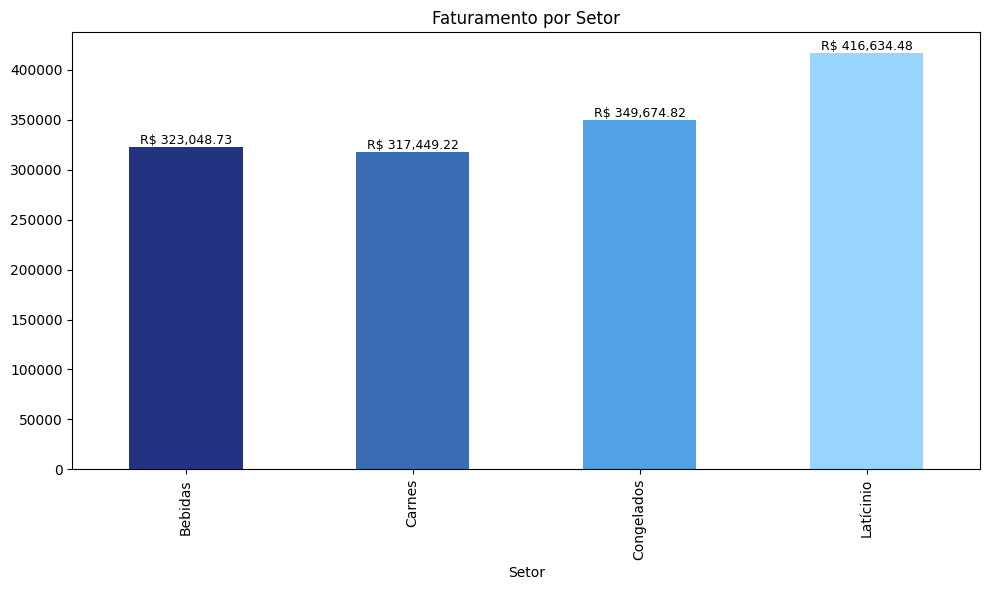

In [141]:
#Gráfico - Faturamento por Setor

#Agrupamento
faturamento_setor = dataset.groupby(['Setor'])['Faturamento'].sum()

#Valores exatos
for i, valor in enumerate(faturamento_setor.values):
    plt.text(i, valor, f"R$ {valor:,.2f}", ha='center', va='bottom', fontsize=9)

#Criação do Gráfico
faturamento_setor.plot(
                        x="Setor",
                        y="Faturamento",
                        kind="bar",
                        title="Faturamento por Setor",
                        color=['#233381','#3A6CB4FF','#50A1E5FF','#5CBEFFA3'],
                        figsize=(10,6)
                      )
plt.tight_layout()
plt.show()

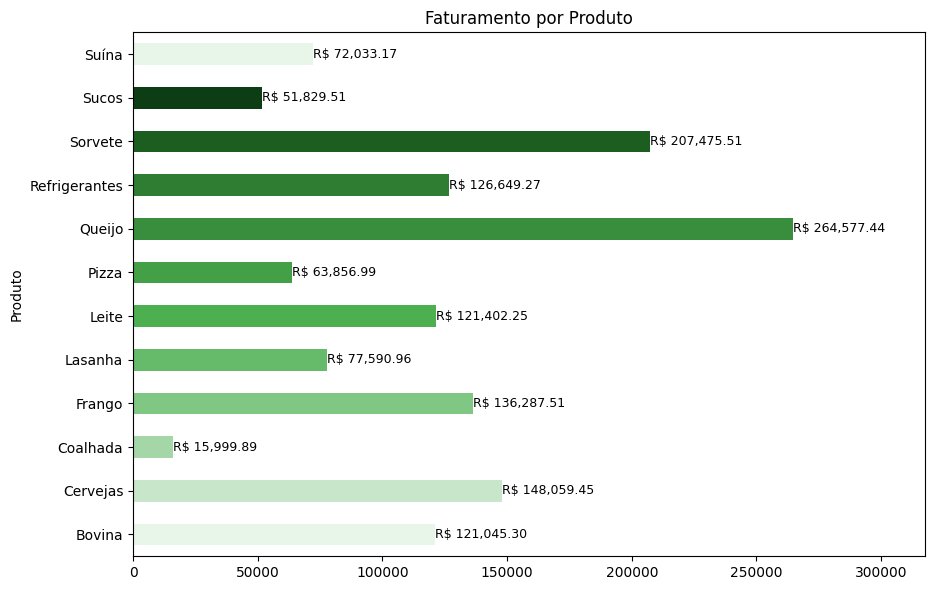

In [165]:
#Gráfico - Faturamento por Produto

#Agrupamento
faturamento_produto = dataset.groupby(['Produto'])['Faturamento'].sum()

#Valores exatos
for i, valor in enumerate(faturamento_produto.values):
    plt.text(valor, i, f"R$ {valor:,.2f}", ha='left', va='center', fontsize=9)

#Criação do Gráfico
faturamento_produto.plot(
                          x="Produto",
                          y="Faturamento",
                          kind="barh",
                          title="Faturamento por Produto",
                          color=['#E8F5E9','#C8E6C9','#A5D6A7','#81C784','#66BB6A','#4CAF50','#43A047','#388E3C','#2E7D32','#1B5E20','#0D3D14'],
                          figsize=(10,6)
                          )
plt.tight_layout()
plt.xlim(0, faturamento_produto.max() * 1.2)
plt.show()

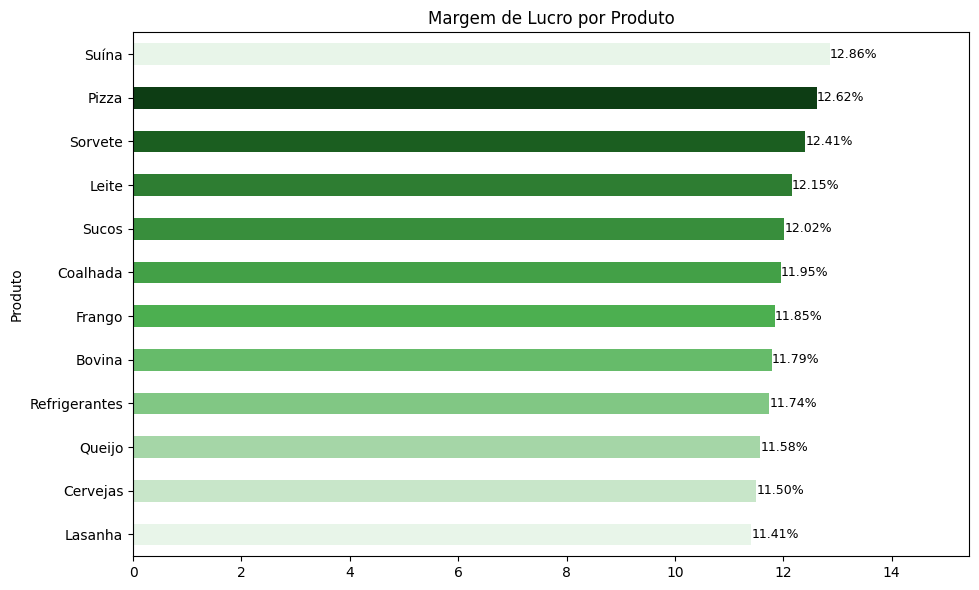

In [163]:
#Gráfico - Margem de Lucro por Produto

#Agrupamento
margemdelucro_produto = dataset.groupby(['Produto'])['Margem de Lucro'].mean().sort_values()*100

#Valores exatos
for i, valor in enumerate(margemdelucro_produto.values):
    plt.text(valor, i, f"{valor:.2f}%", ha='left', va='center', fontsize=9)

#Criação do Gráfico
margemdelucro_produto.plot(
                          x="Produto",
                          y="Margem de Lucro",
                          kind="barh",
                          title="Margem de Lucro por Produto",
                          color=['#E8F5E9','#C8E6C9','#A5D6A7','#81C784','#66BB6A','#4CAF50','#43A047','#388E3C','#2E7D32','#1B5E20','#0D3D14'],
                          figsize=(10,6)
                          )
plt.tight_layout()
plt.xlim(0, margemdelucro_produto.max() * 1.2)
plt.show()

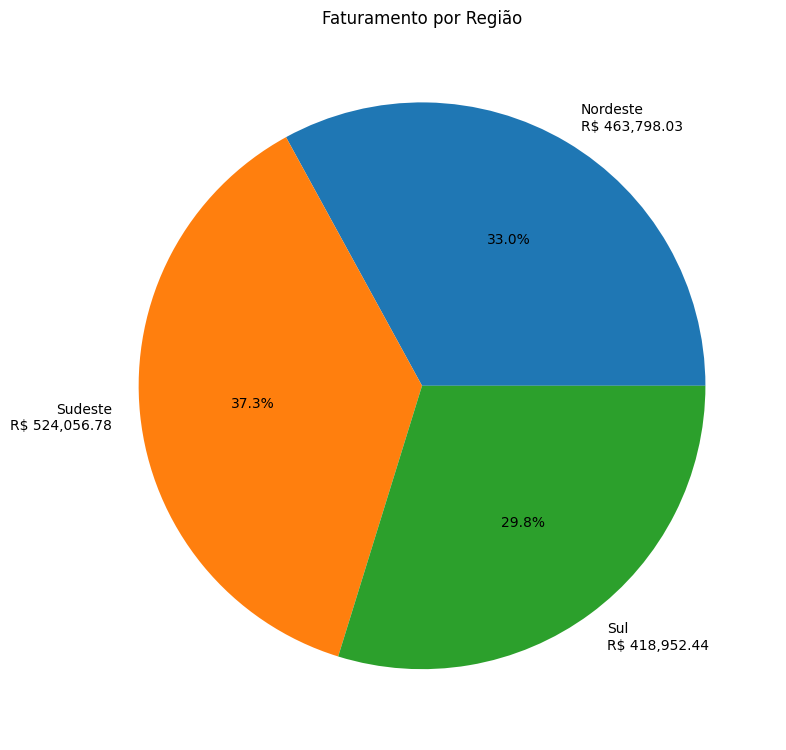

In [143]:
#Gráfico - Faturamento por Região

#Agrupamento
faturamento_regiao = dataset.groupby("Região")["Faturamento"].sum()

#Nomes das regiões e valores
labels = [f"{regiao}\nR$ {valor:,.2f}" for regiao, valor in zip(faturamento_regiao.index, faturamento_regiao.values)]

#Criação do Gráfico
faturamento_regiao.plot(
    kind="pie",
    labels=labels,
    autopct='%1.1f%%',
    figsize=(8, 8),
    title="Faturamento por Região",
)

plt.ylabel("")
plt.tight_layout()
plt.show()

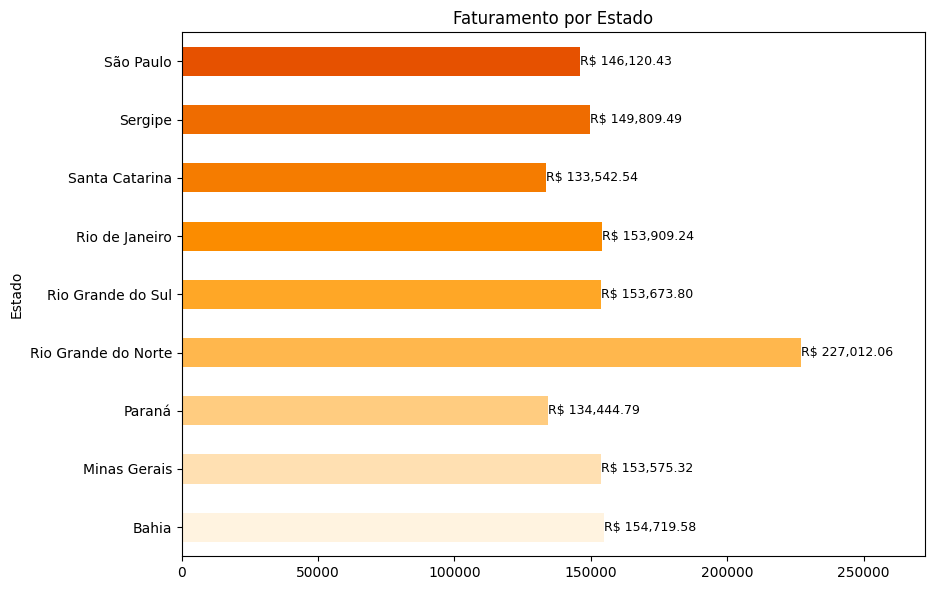

In [168]:
#Gráfico - Faturamento por Estado

#Agrupamento
faturamento_estado = dataset.groupby(['Estado'])['Faturamento'].sum()

#Valores exatos
for i, valor in enumerate(faturamento_estado.values):
    plt.text(valor, i, f"R$ {valor:,.2f}", ha='left', va='center', fontsize=9)

#Criação do Gráfico
faturamento_estado.plot(
                          x="Estado",
                          y="Faturamento",
                          kind="barh",
                          title="Faturamento por Estado",
                          color=['#FFF3E0','#FFE0B2','#FFCC80','#FFB74D','#FFA726','#FB8C00','#F57C00','#EF6C00','#E65100','#BF360C'],
                          figsize=(10,6)
                          )
plt.tight_layout()
plt.xlim(0, faturamento_estado.max() * 1.2)
plt.show()

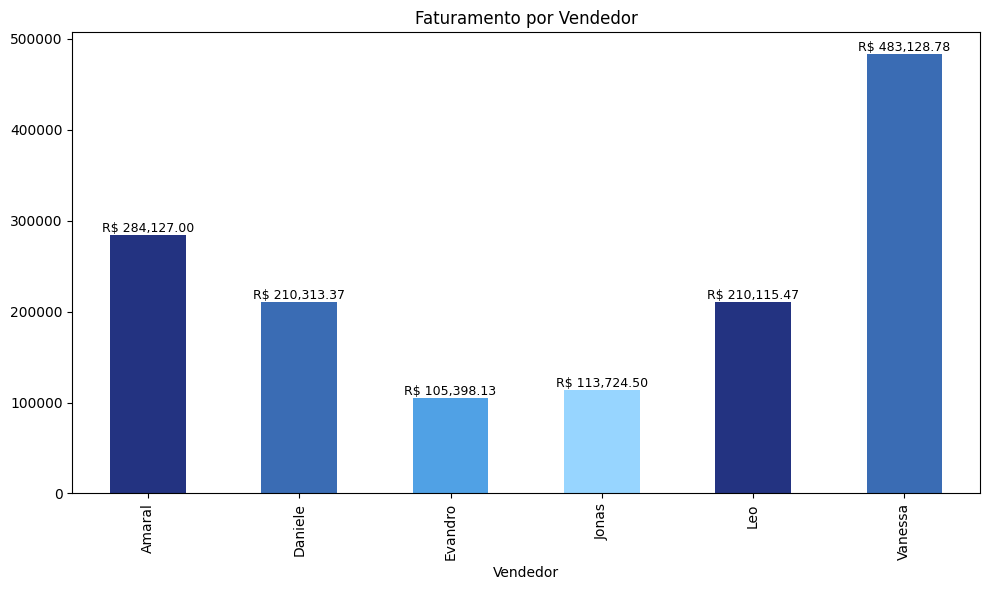

In [154]:
#Gráfico - Faturamento por Vendedor

#Agrupamento
faturamento_vendedor = dataset.groupby(['Vendedor'])['Faturamento'].sum()

#Valores exatos
for i, valor in enumerate(faturamento_vendedor.values):
    plt.text(i, valor, f"R$ {valor:,.2f}", ha='center', va='bottom', fontsize=9)

#Criação do Gráfico
faturamento_vendedor.plot(
                        x="Setor",
                        y="Faturamento",
                        kind="bar",
                        title="Faturamento por Vendedor",
                        color=['#233381','#3A6CB4FF','#50A1E5FF','#5CBEFFA3'],
                        figsize=(10,6)
                      )
plt.tight_layout()
plt.show()

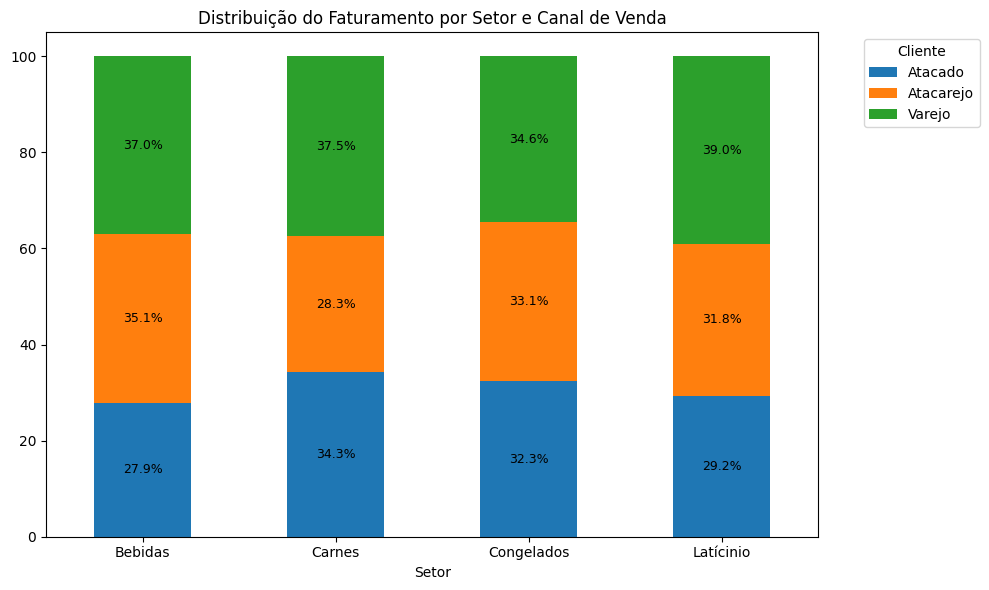

In [153]:
#Gráfico - Setor e Canal de Venda

#Agrupamento
setor_cliente = dataset.groupby(["Setor", "Cliente"])["Faturamento"].sum().unstack()
setor_cliente_pct = setor_cliente.div(setor_cliente.sum(axis=1), axis=0) * 100

#Criação do Gráfico
setor_cliente_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    title="Distribuição do Faturamento por Setor e Canal de Venda",
)

#Porcentagens
for c in plt.gca().containers:
    plt.gca().bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)

plt.legend(title="Cliente", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [169]:
#Agora vou criar uma coluna de mês para fazer as duas ultimas analises

dataset["Mês"] = pd.to_datetime(dataset["Data de Venda"], dayfirst=True).dt.month

meses = {1:'Janeiro', 2:'Fevereiro', 3:'Março', 4:'Abril', 5:'Maio', 6:'Junho',
         7:'Julho', 8:'Agosto', 9:'Setembro', 10:'Outubro', 11:'Novembro', 12:'Dezembro'}

dataset["Mês"] = dataset["Mês"].map(meses)

dataset["Mês"].value_counts()


,count
Mês,
Setembro,150
Novembro,147
Julho,140
Outubro,137
Junho,135
Março,135
Janeiro,132
Abril,126
Dezembro,125


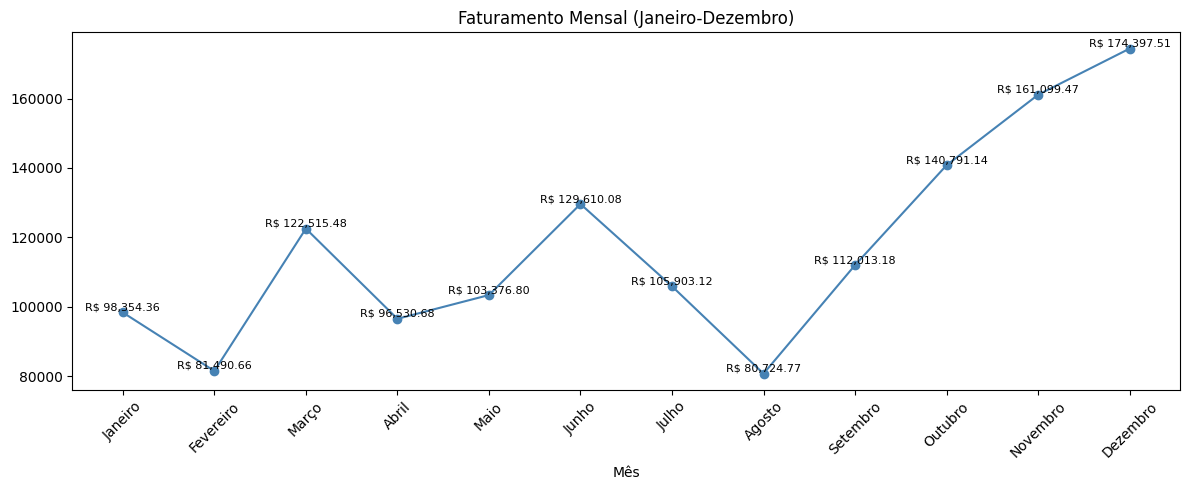

In [178]:
#Gráfico - Faturamento Mensal

#Agrupamento
faturamento_mes = dataset.groupby("Mês")["Faturamento"].sum()

# Ordenar pelos meses corretamente
ordem_meses = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho',
               'Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']
faturamento_mes = faturamento_mes.reindex(ordem_meses).dropna()

#Criação do Gráfico
faturamento_mes.plot(
    kind="line",
    figsize=(12, 5),
    title="Faturamento Mensal (Janeiro-Dezembro)",
    marker='o',
    color='steelblue'
)

# Valores exatos
for i, valor in enumerate(faturamento_mes.values):
    plt.text(i, valor , f"R$ {valor:,.2f}", ha='center', va='bottom', fontsize=8)

#Para todos meses aparecer
plt.xticks(range(len(faturamento_mes)), faturamento_mes.index, rotation=45)
plt.tight_layout()
plt.show()

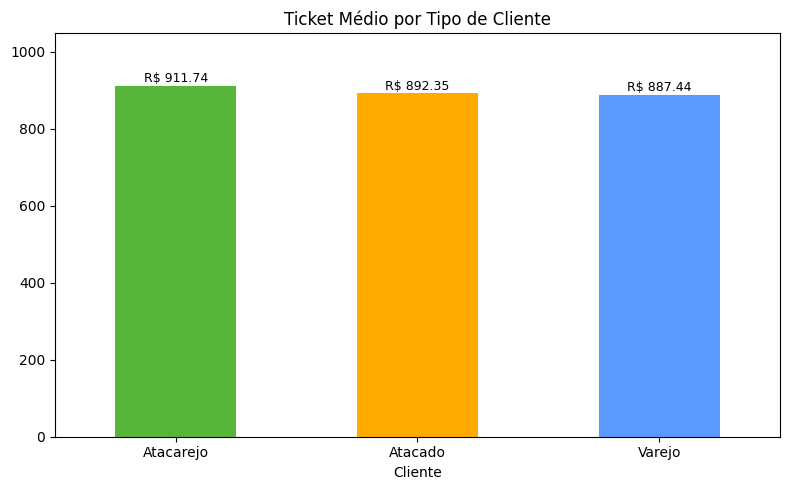

In [184]:
#Gráfico - Ticket Médio por Cliente
#Agrupamento
ticket_medio = dataset.groupby("Cliente")["Faturamento"].mean().sort_values(ascending=False)

#Criação do Gráfico
ticket_medio.plot(
    kind="bar",
    figsize=(8, 5),
    title="Ticket Médio por Tipo de Cliente",
    color=['#57B53AFF','#FFAA00FF','#5C99FFFF']
)

#Valores exatos
for i, valor in enumerate(ticket_medio.values):
    plt.text(i, valor + 1, f"R$ {valor:,.2f}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, ticket_medio.max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()